# One knee, two views — 2D and 3D from one series

This is **M6b** of the plan (`img_preprocess_all_model_sudocode.ipynb` §3), built early and on
purpose: the viewer is what debugs the image pipeline *visually*, and it is the graded
deliverable of the Wagon side of the project — *"a 3D view (3 axes) of the MRI, problem areas
in colour, plus 12 confidence percentages, never a sentence"*.

It reads **one file type only** — `data/volumes/<SeriesUID>.npz`, the T3 mirror — and needs no
DICOM, no model, no GPU, no internet. Everything below runs on `numpy + scipy + matplotlib`.

| § | view | what it answers |
|---|---|---|
| 2 | contact sheet · 24 slices | is this a knee, in the plane and contrast we asked for? |
| 3 | neighbourhood *i-1, i, i+1* | the "a real finding shows on the neighbours too" prior — **measured** |
| 4 | slice scrub | the radiologist's actual gesture, with a slider |
| 6 | tri-planar + crosshair | `view_2d` of the plan; also where the reslice blur becomes undeniable |
| 7 | MIP ×3 | 3D at a glance, zero parameters |
| 8 | volume render + turntable | `view_3d` — a 40-line numpy raycaster, ~30 ms a frame |
| 9 | three planes in space | the literal "3 axes" of the brief |
| 10 | colour overlay | the M6a display contract, on a **placeholder** heat volume |
| 11 | the study's real planes | why we show three acquisitions and never fuse them |
| 12 | render pack | the single `.npz` the app will load instead of all of this |

---
## 0. Sudocode

The whole viewer, before any of it exists. Every function below is implemented in this
notebook and is meant to move to `src/viz/viewer.py` unchanged.

```python
pick(study)                        # 58 gold studies carry all 12 adjudicated labels; use one
    series = train_index[study]    # ~5.5 rows per study: plane x fluid-sensitive
    take SAG_FLUID                 # 94.2% of studies have one -> the render-pack anatomy

load(series)   -> V uint8 (24,224,224)     # the mirror. 24 slices, 130 mm FOV, M2's output
window(V)      -> G float 0..1             # one p1-p99.5 window per SERIES, never per slice

2D  contact_sheet(G)               # all 24 at once
    neighbourhood(G, i)            # i-1, i, i+1  <- the correlation prior of tech_constraints.md
    scrub(G)                       # the same stack as an animation, with a slider

    to_iso(G, slice_mm) -> W (84,130,130)  # 1 mm voxels; slice_mm is ASSUMED, see §5
    triplanar(W, centre)           # three cuts through one voxel + crosshair

3D  mip(W)                         # max along each axis: no parameters, nothing to tune wrong
    raycast(W, azim)               # front-to-back alpha compositing, pure numpy
    turntable(W)                   # 36 raycasts -> a slider
    planes3d(W)                    # the three cuts drawn in space

colour                             # M6a's output does not exist yet -> stand in for it (§7 of the plan)
    heat = fake_blob(W.shape)      # same contract: float 0..1, one volume per label
    alpha = f(heat) * confidence   # DISPLAY_CONTRACT: alpha always scaled by confidence
    confidence < tau -> no colour  # not a faint overlay. The percentage still ships
    heat < floor    -> no paint    # a second, different gate: the tail of a CAM is noise
    every view above takes heat=None and still works

pack(study) -> data/render_packs/<study>.npz    # gray_iso, heat_iso, spacing, probs[12]
                                                # the app loads this. It never sees the mirror
```

---
## 1. Setup — and the two constants everything downstream inherits

`FOV_MM` is fact: M2 crops every series to a constant physical extent before resizing.
`SLICE_MM` is **not** — the mirrored `.npz` carries pixels and nothing else. It is the one
assumption in this notebook, it only affects the *z scale* of §5–§12, and it is a one-line fix
the day M2 writes spacing into the pack.

In [2]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy import ndimage as ndi

ROOT = Path.cwd()
while not (ROOT/".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT/"data"

LABELS = ['ACL','MCL','Medial Meniscus','Lateral Meniscus','Medial OA','Lateral OA',
          'PF OA','Effusion','Synovitis',"Baker's",'Contusion','Fracture']   # submission order. NEVER sort.

FOV_MM   = 130.0   # M2 crop_to_physical_extent -> every mirrored volume covers 130 mm in-plane
SLICE_MM = 3.5     # ASSUMED. The mirror has no spacing; typical knee MRI is 3-4 mm through-plane
ISO_MM   = 1.0     # voxel size of every 3D view below

TAU_CONF   = 0.30  # DISPLAY_CONTRACT: below this confidence a label ships its % and NO colour
HEAT_FLOOR = 0.30  # and within a drawn map, only values above this are painted

INK, MUTED, HUE = "#1f2328", "#6b7280", "#3b6ea5"
plt.rcParams.update({"figure.facecolor": "white", "savefig.facecolor": "white",
                     "axes.titlesize": 9, "axes.titlecolor": INK})

idx     = pd.read_csv(DATA/"meta"/"train_index.csv")
on_disk = {p.name for p in (DATA/"volumes").glob("*.npz")}
idx["on_disk"] = idx.npz.isin(on_disk)

print(f"index      : {len(idx):,} series / {idx.StudyInstanceUID.nunique():,} studies")
print(f"mirrored   : {idx.on_disk.sum():,} volumes on disk ({idx.on_disk.mean():.1%})")
print(f"gold       : {idx[idx.has_labels == 1].StudyInstanceUID.nunique()} studies with all 12 labels")
print(f"in-plane   : {FOV_MM/224:.2f} mm/px   through-plane: {SLICE_MM} mm   -> {SLICE_MM/(FOV_MM/224):.1f}x anisotropic")

index      : 24,371 series / 4,407 studies
mirrored   : 24,371 volumes on disk (100.0%)
gold       : 58 studies with all 12 labels
in-plane   : 0.58 mm/px   through-plane: 3.5 mm   -> 6.0x anisotropic


## 1b. Pick one study, and resolve its four slots

The slots are the plan's §2 constants. A study averages 5.5 series; the viewer only ever needs
**one** of them for anatomy (`SAG_FLUID`, present for 94.2% of studies) — the other three are
here so §11 can show what a study actually contains.

In [3]:
SLOTS = [("SAG_FLUID", "Sagittal", 1),   # fluid-sensitive: fat dark, fluid/oedema bright
         ("SAG_STRUCT","Sagittal", 0),   # structural: anatomy, not pathology
         ("COR_FLUID", "Coronal",  1),
         ("AX_FLUID",  "Axial",    1)]

def study_slots(study):
    """The 4 fixed slots of §2, resolved against what is actually mirrored. None = missing, never imputed."""
    rows = idx[(idx.StudyInstanceUID == study) & idx.on_disk]
    out  = {}
    for name, plane, fluid in SLOTS:
        m = rows[(rows.Anatomical_Plane == plane) & (rows.Fluid_Sensitive == fluid)]
        out[name] = m.SeriesInstanceUID.iloc[0] if len(m) else None
    return out

# A gold study (all 12 labels adjudicated) that has all three planes mirrored, and a torn ACL
# so there is something to look for. sorted() so this notebook picks the same knee every run.
gold     = idx[(idx.has_labels == 1) & idx.on_disk]
three    = gold.groupby("StudyInstanceUID").Anatomical_Plane.nunique().pipe(lambda s: set(s[s == 3].index))
STUDY    = sorted(set(gold.loc[gold.ACL == 1, "StudyInstanceUID"]) & three)[0]
slots    = study_slots(STUDY)
SERIES   = slots["SAG_FLUID"]

truth = idx.loc[idx.StudyInstanceUID == STUDY, LABELS].iloc[0]
print("study :", STUDY[-18:], "  (uid truncated for reading)")
print("truth :", ", ".join(f"{c}" for c in LABELS if truth[c] == 1), " <- adjudicated positives\n")
print(pd.Series({k: (v[-18:] if v else "— missing —") for k, v in slots.items()}, name="series").to_frame())
print(f"\nthe study holds {len(idx[(idx.StudyInstanceUID == STUDY) & idx.on_disk])} mirrored series in total;"
      f" the viewer uses SAG_FLUID for anatomy.")

study : 964005983002209238   (uid truncated for reading)
truth : ACL, Medial Meniscus  <- adjudicated positives

                        series
SAG_FLUID   777336404933338336
SAG_STRUCT  642153746249112051
COR_FLUID   337909203260865351
AX_FLUID    398702944383827602

the study holds 9 mirrored series in total; the viewer uses SAG_FLUID for anatomy.


---
## 2. The unit of work — one series is `uint8 (24, 224, 224)`

`window` applies **one** intensity window to the whole series, pooled over slices — the same
rule M2 used when it wrote the uint8. Windowing slice-by-slice would make each slice look good
and the stack incoherent, which is exactly what breaks a 3D render.

In [4]:
def load_series(series_uid):
    """The mirror: one array per file. The key name is not part of the contract, the shape is."""
    with np.load(DATA/"volumes"/f"{series_uid}.npz") as z:
        return z[z.files[0]]

def window(V, lo=1.0, hi=99.5):
    """One p1-p99.5 window per SERIES -> float 0..1. Slice-wise windowing destroys stack coherence."""
    a, b = np.percentile(V, [lo, hi])
    return np.clip((V.astype(np.float32) - a) / max(b - a, 1e-6), 0.0, 1.0)

V = load_series(SERIES)
G = window(V)
print(f"raw    : {V.shape} {V.dtype}   min {V.min()} max {V.max()}   {V.nbytes/2**20:.1f} MiB")
print(f"windowed: {G.shape} float32   background is {(G < .05).mean():.0%} of the voxels")
print(f"physical: {FOV_MM:.0f} x {FOV_MM:.0f} mm in-plane, {G.shape[0]*SLICE_MM:.0f} mm through-plane (assumed)")

raw    : (24, 224, 224) uint8   min 0 max 252   1.1 MiB
windowed: (24, 224, 224) float32   background is 48% of the voxels
physical: 130 x 130 mm in-plane, 84 mm through-plane (assumed)


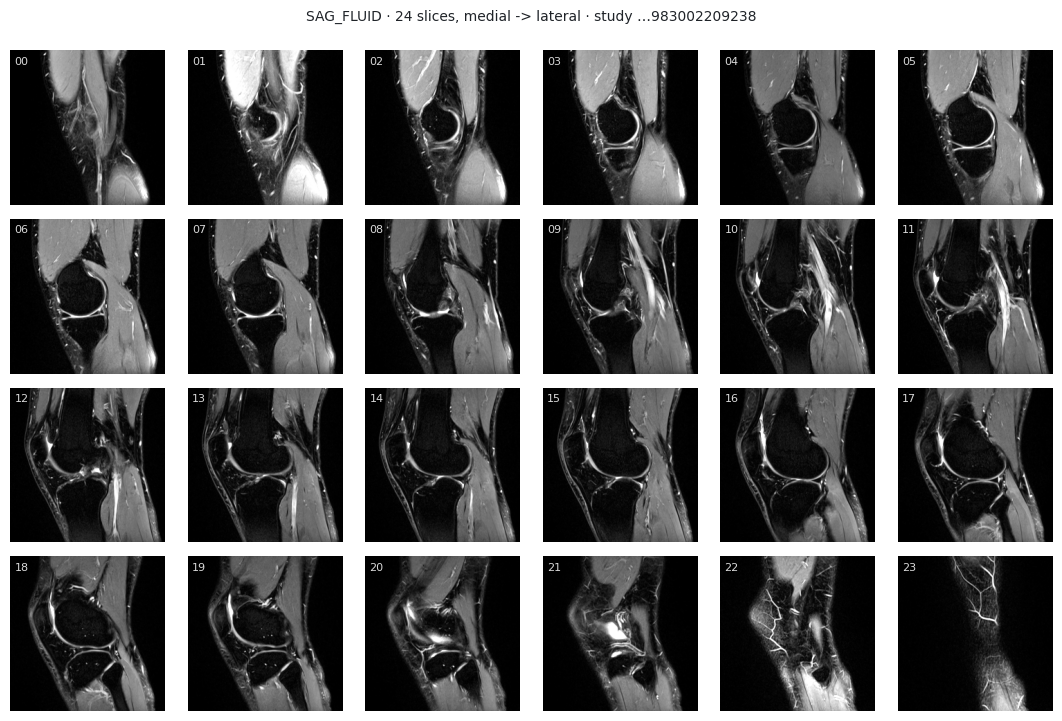

In [5]:
def contact_sheet(G, cols=6, title="", every=1):
    """All 24 slices at once. The first thing to look at, and the fastest way to spot a bad series."""
    sl = list(range(0, len(G), every))
    rows = int(np.ceil(len(sl)/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.8, rows*1.8), dpi=100)
    for ax, i in zip(axes.ravel(), sl):
        ax.imshow(G[i], cmap="gray", vmin=0, vmax=1)
        ax.text(6, 20, f"{i:02d}", color="w", fontsize=8, alpha=.85)
    for ax in axes.ravel(): ax.set_axis_off()
    fig.suptitle(title, fontsize=10, color=INK, y=.995)
    plt.tight_layout(); plt.show()

contact_sheet(G, title=f"SAG_FLUID · 24 slices, medial -> lateral · study …{STUDY[-12:]}")

Read it as a sweep: the stack enters medially, crosses the intercondylar notch in the middle
slices — where the cruciates live — and exits laterally. Slices 0 and 23 are mostly soft tissue;
they are still 2 of the 24 the encoder will see, which is why per-slice attention (§5 of the
plan) is in the specialist head at all.

---
## 3. The neighbourhood — the prior from `tech_constraints.md`, measured

> *"there should be high prob that the injury appears in img-1 and img+1 of the sequence"*

That is a claim about the data, so measure it instead of assuming it: correlate each slice with
its neighbour, and with a far-away slice from the same series.

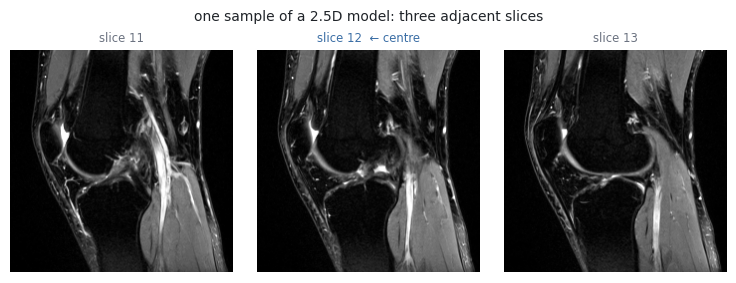

adjacent slices (|di| = 1) : r = 0.801   (min 0.602)
distant slices (|di| >= 8) : r = 0.409
=> a structure seen on slice i is largely still there on i±1. The prior holds on this series;
   it is also why 24 slices at 3.5 mm are not 24 independent looks at the knee.


In [6]:
def neighbourhood(G, i, k=1, title=""):
    """Slices i-k .. i+k side by side — what a 2.5D model actually consumes as one sample."""
    ii = [j for j in range(i-k, i+k+1) if 0 <= j < len(G)]
    fig, axes = plt.subplots(1, len(ii), figsize=(2.4*len(ii), 2.7), dpi=105)
    for ax, j in zip(np.atleast_1d(axes), ii):
        ax.imshow(G[j], cmap="gray", vmin=0, vmax=1); ax.set_axis_off()
        ax.set_title(f"slice {j}" + ("  ← centre" if j == i else ""), fontsize=8,
                     color=(HUE if j == i else MUTED))
    fig.suptitle(title, fontsize=9.5, color=INK)
    plt.tight_layout(); plt.show()

flat  = G.reshape(len(G), -1)
near  = [np.corrcoef(flat[i], flat[i+1])[0, 1] for i in range(len(G)-1)]
far   = [np.corrcoef(flat[i], flat[j])[0, 1]
         for i in range(len(G)) for j in range(len(G)) if abs(i-j) >= 8]

MID = len(G)//2
neighbourhood(G, MID, title="one sample of a 2.5D model: three adjacent slices")
print(f"adjacent slices (|di| = 1) : r = {np.mean(near):.3f}   (min {np.min(near):.3f})")
print(f"distant slices (|di| >= 8) : r = {np.mean(far):.3f}")
print(f"=> a structure seen on slice i is largely still there on i±1. The prior holds on this series;")
print(f"   it is also why 24 slices at 3.5 mm are not 24 independent looks at the knee.")

---
## 4. Scrub — the gesture radiologists actually make

`ipywidgets` is not in the environment and is not worth a dependency here: a matplotlib
animation rendered with `to_jshtml()` ships its own play button and slider, works in a plain
notebook, on GitHub-rendered HTML, and inside Streamlit later.

In [7]:
from IPython.display import HTML, display

def scrub(G, cmap="gray", fps=6, size=4.48, title=""):
    """The stack as an animation: play/pause + a frame slider, no widget dependency."""
    fig, ax = plt.subplots(figsize=(size, size), dpi=100)
    ax.set_axis_off(); fig.subplots_adjust(0, 0, 1, 1)
    im  = ax.imshow(G[0], cmap=cmap, vmin=0, vmax=1, animated=True)
    txt = ax.text(.02, .97, "", transform=ax.transAxes, color="w", fontsize=9, va="top")
    def draw(i):
        im.set_data(G[i]); txt.set_text(f"{title}\nslice {i:02d}/{len(G)-1}")
        return im, txt
    anim = animation.FuncAnimation(fig, draw, frames=len(G), interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml(fps=fps))

scrub(G, title="SAG_FLUID")

---
## 5. From a stack of pictures to a volume

Nothing above is 3D: 24 pictures 3.5 mm apart are a stack, and any 3D operation on them
implicitly treats a voxel as a cube. `to_iso` makes that explicit — resample once, to 1 mm, and
every view after this shares one geometry.

The 6× anisotropy is the acquisition's, not ours. It is the reason §11 refuses to fuse planes.

In [8]:
def to_iso(G, iso_mm=ISO_MM, fov_mm=FOV_MM, slice_mm=SLICE_MM):
    """(24,224,224) at 0.58 x 0.58 x 3.5 mm  ->  ~(84,130,130) at 1 mm isotropic.
       order=1: linear. Nothing here invents detail — the through-plane blur below is real."""
    z = (slice_mm/iso_mm, (fov_mm/G.shape[1])/iso_mm, (fov_mm/G.shape[2])/iso_mm)
    return np.clip(ndi.zoom(G, z, order=1), 0, 1).astype(np.float32)

W = to_iso(G)
print(f"{G.shape} -> {W.shape} at {ISO_MM} mm/voxel   ({W.nbytes/2**20:.1f} MiB in float32)")
print(f"axes of W: 0 = medial↔lateral (the stack, {SLICE_MM} mm sampling)")
print(f"           1 = superior↔inferior, 2 = anterior↔posterior ({FOV_MM/224:.2f} mm sampling)")

(24, 224, 224) -> (84, 130, 130) at 1.0 mm/voxel   (5.4 MiB in float32)
axes of W: 0 = medial↔lateral (the stack, 3.5 mm sampling)
           1 = superior↔inferior, 2 = anterior↔posterior (0.58 mm sampling)


---
## 6. `view_2d` — tri-planar with a crosshair

One voxel, three cuts, one crosshair linking them. **Build this first** (plan, M6b): it is the
view that catches a wrong laterality flip, a mis-ordered stack, or a broken window, and it
catches them in a second.

The middle and right panels are *resliced*: they are the same 24 acquired slices seen edge-on,
transposed so that all three panels are read in the usual orientation. Their blur is the 6×
anisotropy, drawn.

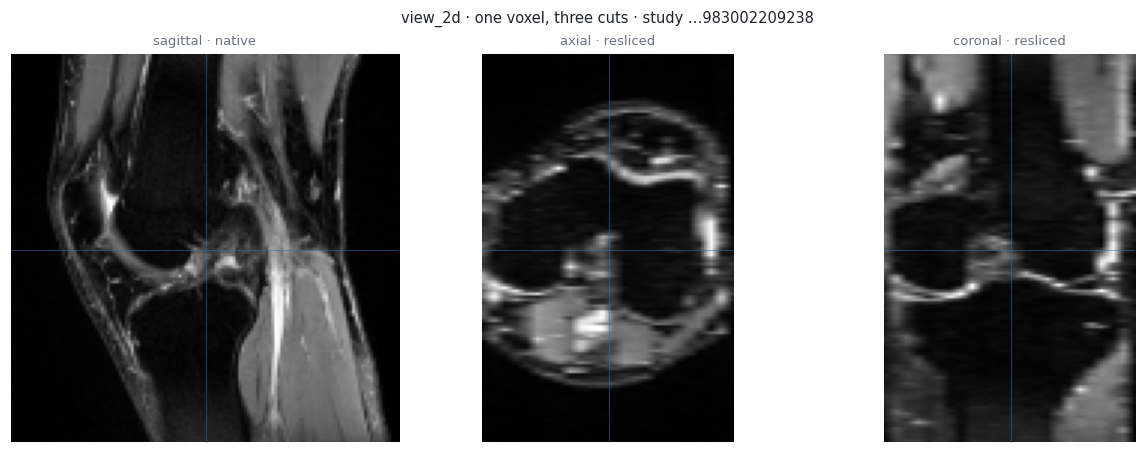

In [9]:
def triplanar(W, centre=None, heat=None, conf=1.0, tau=TAU_CONF, floor=HEAT_FLOOR, title=""):
    """The three orthogonal cuts through one voxel of an isotropic volume, plus the crosshair.

    The two reslices are transposed so all three panels are read in the radiological
    orientation — superior up on the coronal, anterior up on the axial."""
    cz, cy, cx = centre or [s//2 for s in W.shape]
    cut = lambda A: [A[cz], A[:, cy, :].T, A[:, :, cx].T]
    names = ["sagittal · native", "axial · resliced", "coronal · resliced"]
    cross = [(cx, cy), (cz, cx), (cz, cy)]
    hp = None if heat is None else cut(heat)
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2), dpi=105, constrained_layout=True)
    for k, (ax, img, name, (px, py)) in enumerate(zip(axes, cut(W), names, cross)):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1, aspect="equal")
        if hp is not None and conf >= tau:                       # confidence gate, first
            h = np.clip((hp[k] - floor)/(1 - floor), 0, 1)       # heat floor, second
            ax.imshow(np.ma.masked_where(h <= 0, h), cmap="inferno", vmin=0, vmax=1,
                      alpha=float(conf)*.5, aspect="equal")
        ax.axhline(py, color=HUE, lw=.7, alpha=.55); ax.axvline(px, color=HUE, lw=.7, alpha=.55)
        ax.set_title(name, color=MUTED); ax.set_axis_off()
    fig.suptitle(title, fontsize=10, color=INK)
    plt.show()

triplanar(W, title=f"view_2d · one voxel, three cuts · study …{STUDY[-12:]}")

---
## 7. MIP — 3D at a glance, with nothing to tune

Maximum intensity projection along each axis. It has no transfer function, no opacity, no
threshold: whatever is brightest wins. On a **fluid-sensitive** series brightest ≈ fluid, so the
MIP is already a crude effusion/oedema map — and a free sanity check on the volume before
spending any parameters on §8.

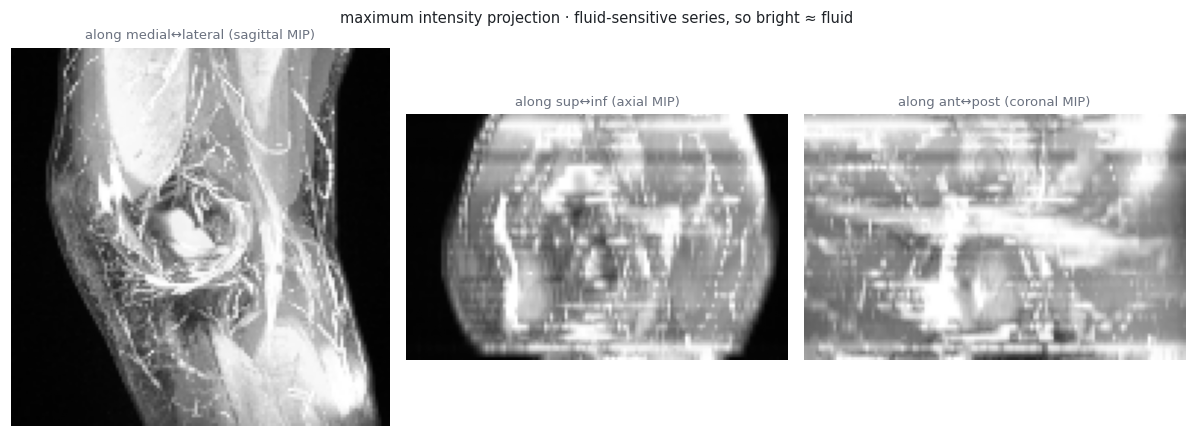

In [10]:
def mip(W, title=""):
    names = ["along medial↔lateral (sagittal MIP)", "along sup↔inf (axial MIP)", "along ant↔post (coronal MIP)"]
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2), dpi=105)
    for k, (ax, n) in enumerate(zip(axes, names)):
        ax.imshow(W.max(axis=k), cmap="gray", vmin=0, vmax=1, aspect="equal")
        ax.set_title(n, color=MUTED); ax.set_axis_off()
    fig.suptitle(title, fontsize=10, color=INK)
    plt.tight_layout(); plt.show()

mip(W, title="maximum intensity projection · fluid-sensitive series, so bright ≈ fluid")

---
## 8. `view_3d` — a volume renderer in 40 lines of numpy

No VTK, no GPU, no WebGL. Rotate the volume, then composite front-to-back along the view axis:

$$C=\sum_k T_k\,\alpha_k\,c_k,\qquad T_k=\prod_{j<k}(1-\alpha_j)$$

with $\alpha$ from a transfer function on intensity. `cumprod` does the whole ray in one pass,
so a frame costs ~30 ms — fast enough to turn the crank 36 times and get a turntable, which is
what the demo needs (precomputed, cannot fail live).

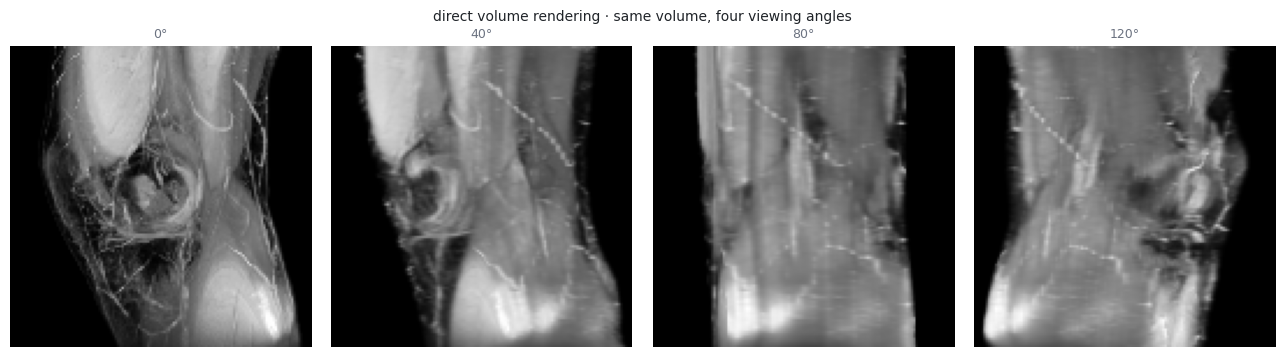

In [11]:
def raycast(W, azim=0.0, elev=0.0, heat=None, conf=1.0, tau=TAU_CONF, floor=HEAT_FLOOR,
            lo=.05, gamma=1.6, opacity=.5, heat_op=.35, heat_gamma=2.5, cmap="inferno"):
    """Front-to-back alpha compositing along axis 0, after rotating the volume into view.

    heat: same-shaped float 0..1 volume (M6a's output). conf: the head's probability for that
    label. Two separate gates, and they are not interchangeable:
      tau   — CONFIDENCE. Below it the overlay is not drawn at all, at any opacity.
      floor — HEAT VALUE. The tail of the map is noise; only the core is worth colouring."""
    def turn(A):
        A = ndi.rotate(A, azim, axes=(0, 2), reshape=False, order=1) if azim else A
        return ndi.rotate(A, elev, axes=(0, 1), reshape=False, order=1) if elev else A

    x = np.clip((turn(W) - lo)/(1 - lo), 0, 1)          # transfer function: window ...
    a = np.clip(x**gamma * opacity, 0, 1)               # ... then intensity -> opacity
    rgb = np.repeat(x[..., None], 3, -1)                # grey anatomy

    if heat is not None and conf >= tau:                         # the gate. Not a faint overlay
        h  = np.clip((turn(heat) - floor)/(1 - floor), 0, 1)
        ah = (h**heat_gamma) * heat_op * float(conf)             # alpha ∝ confidence, always
        hot = plt.get_cmap(cmap)(h)[..., :3].astype(np.float32)
        a2  = 1 - (1 - a)*(1 - ah)
        rgb = (a[..., None]*rgb + ah[..., None]*hot)/np.maximum(a2[..., None], 1e-6)
        a   = a2

    T   = np.cumprod(np.concatenate([np.ones_like(a[:1]), 1 - a[:-1]]), axis=0)
    img = (T[..., None] * a[..., None] * rgb).sum(axis=0)
    return np.clip(img/max(img.max(), 1e-6), 0, 1)

def cube(W, pad=1.0):
    """Rotation needs room: centre the volume in a cube so nothing leaves the frame."""
    n = int(max(W.shape)*pad)
    out = np.zeros((n, n, n), W.dtype)
    o = [(n - s)//2 for s in W.shape]
    out[o[0]:o[0]+W.shape[0], o[1]:o[1]+W.shape[1], o[2]:o[2]+W.shape[2]] = W
    return out

Wc = cube(W)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), dpi=100)
for ax, az in zip(axes, [0, 40, 80, 120]):
    ax.imshow(raycast(Wc, az)); ax.set_title(f"{az}°", color=MUTED); ax.set_axis_off()
fig.suptitle("direct volume rendering · same volume, four viewing angles", fontsize=10, color=INK)
plt.tight_layout(); plt.show()

In [12]:
def turntable(W, frames=24, fps=12, size=4.2, heat=None, conf=1.0, title="", **kw):
    """One full revolution. Precomputed frames = a demo that cannot fail on stage."""
    imgs = [raycast(W, az, heat=heat, conf=conf, **kw)
            for az in np.linspace(0, 360, frames, endpoint=False)]
    fig, ax = plt.subplots(figsize=(size, size), dpi=100)
    ax.set_axis_off(); fig.subplots_adjust(0, 0, 1, 1)
    im  = ax.imshow(imgs[0], animated=True)
    txt = ax.text(.02, .97, "", transform=ax.transAxes, color="w", fontsize=9, va="top")
    def draw(i):
        im.set_data(imgs[i]); txt.set_text(f"{title}\n{i*360//frames:3d}°")
        return im, txt
    anim = animation.FuncAnimation(fig, draw, frames=frames, interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml(fps=fps))

%time turntable(Wc, title="SAG_FLUID · anatomy only")

CPU times: user 1.62 s, sys: 14.6 ms, total: 1.64 s
Wall time: 1.65 s


Two things this render tells the truth about. Around 0° the knee is sharp — that is the acquired
sagittal plane. Around 90° it smears into stripes: 24 samples spread over 84 mm, seen edge-on.
A prettier renderer would hide that; this one should not.

---
## 9. The three planes, drawn in space

The brief's *"3D view (3 axes)"*, taken literally: the same three cuts as §6, placed where they
actually sit relative to each other. This is the frame the colour of §10 is read in — a spot on
one 2D panel means nothing until you can see which of the three planes it lives on.

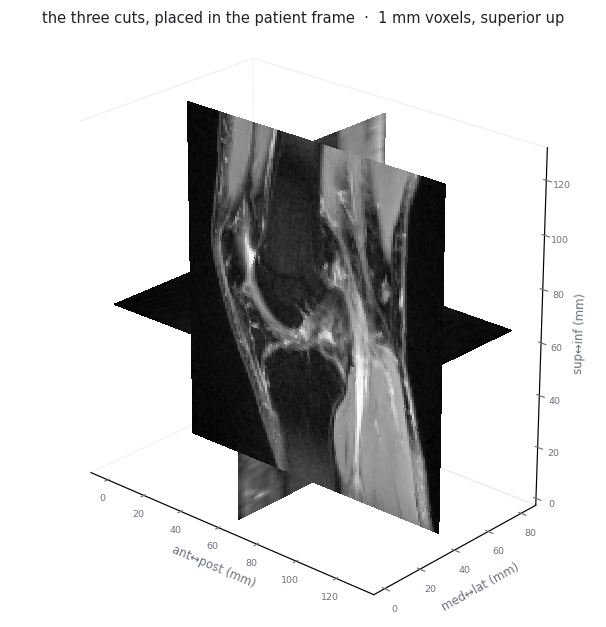

In [13]:
def planes3d(W, centre=None, elev=24, azim=-48, size=6.6, gamma=.65, title=""):
    """The tri-planar of §6, as three textured surfaces placed in the patient's own frame:
       x = anterior↔posterior, y = medial↔lateral (the acquired stack), z = superior↔inferior."""
    cz, cy, cx = centre or [s//2 for s in W.shape]      # cz med↔lat · cy sup↔inf · cx ant↔post
    nz, ny, nx = W.shape
    show = np.clip(W, 0, 1)**gamma                      # display gamma only; the volume is untouched
    grey = plt.get_cmap("gray")
    kw   = dict(rstride=1, cstride=1, shade=False, linewidth=0, antialiased=False)

    fig = plt.figure(figsize=(size, size*.92), dpi=105)
    ax  = fig.add_subplot(111, projection="3d")

    X,  Z  = np.meshgrid(np.arange(nx), np.arange(ny))          # sagittal: vertical, spans x,z
    ax.plot_surface(X.astype(float), np.full_like(X, float(cz), dtype=float), (ny-1.)-Z,
                    facecolors=grey(show[cz]), **kw)
    Xa, Ya = np.meshgrid(np.arange(nx), np.arange(nz))          # axial: horizontal, spans x,y
    ax.plot_surface(Xa.astype(float), Ya.astype(float),
                    np.full_like(Xa, (ny-1.)-cy, dtype=float),
                    facecolors=grey(show[:, cy, :]), **kw)
    Yc, Zc = np.meshgrid(np.arange(nz), np.arange(ny))          # coronal: vertical, spans y,z
    ax.plot_surface(np.full_like(Yc, float(cx), dtype=float), Yc.astype(float), (ny-1.)-Zc,
                    facecolors=grey(show[:, :, cx].T), **kw)

    ax.set_box_aspect((nx, nz, ny)); ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("ant↔post (mm)", fontsize=8, color=MUTED, labelpad=-4)
    ax.set_ylabel("med↔lat (mm)",  fontsize=8, color=MUTED, labelpad=-4)
    ax.set_zlabel("sup↔inf (mm)",  fontsize=8, color=MUTED, labelpad=-4)
    ax.tick_params(labelsize=6.5, colors=MUTED, pad=-1)
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_facecolor("white"); a.pane.set_edgecolor("#e5e7eb")
    ax.grid(False)
    ax.set_title(title, fontsize=10, color=INK)
    plt.tight_layout(); plt.show()

planes3d(W, title="the three cuts, placed in the patient frame  ·  1 mm voxels, superior up")

---
## 10. Colour — the display contract, on a placeholder

M6a does not exist yet, so this is the plan's own unblocking trick (§7): **generate a fake heat
volume that satisfies the contract and build the viewer against it.** When real CAMs land it is
a one-line swap, and every function above already accepts `heat=`.

The contract, restated where it is implemented:

- overlay alpha is **always** multiplied by the predicted confidence;
- below **τ = confidence** there is *no* overlay, not a faint one — and that is a different
  threshold from the **heat floor**, which decides how much of a *drawn* map gets painted;
- a label that fails M6a's QC ships with **no colour at all** — the percentage still ships;
- the app returns 12 percentages and colour, **never a sentence**.

In [14]:
def fake_heat(shape, centre_frac=(.5, .47, .5), sigma_mm=12., iso_mm=ISO_MM):
    """M6a's contract, stand-in: float 0..1, one volume per label, same grid as the anatomy.
       Centred because M2 crops 130 mm around the knee -> the middle of the cube IS the joint."""
    c = [f*s for f, s in zip(centre_frac, shape)]
    g = np.mgrid[0:shape[0], 0:shape[1], 0:shape[2]].astype(np.float32)
    d2 = sum((g[k] - c[k])**2 for k in range(3))
    return np.exp(-d2/(2*(sigma_mm/iso_mm)**2)).astype(np.float32)

# stand-in confidences: the soft report labels already in the index. Real ones come from M5.
soft = idx.loc[idx.StudyInstanceUID == STUDY, [f"soft_{c}" for c in LABELS]].iloc[0]
probs = pd.Series(soft.values, index=LABELS, dtype=float)
LABEL = "ACL"

Hc = fake_heat(Wc.shape)
print(f"label     : {LABEL}   confidence {probs[LABEL]:.2f}   (soft report label — placeholder for M5)")
print(f"heat      : {Hc.shape} float32 in [{Hc.min():.2f}, {Hc.max():.2f}]  <- SYNTHETIC, a Gaussian blob")
print(f"gates     : confidence tau = {TAU_CONF}, heat floor = {HEAT_FLOOR}"
      f"  -> {'overlay drawn' if probs[LABEL] >= TAU_CONF else 'NO overlay: percentage only'}")

label     : ACL   confidence 0.99   (soft report label — placeholder for M5)
heat      : (130, 130, 130) float32 in [0.00, 1.00]  <- SYNTHETIC, a Gaussian blob
gates     : confidence tau = 0.3, heat floor = 0.3  -> overlay drawn


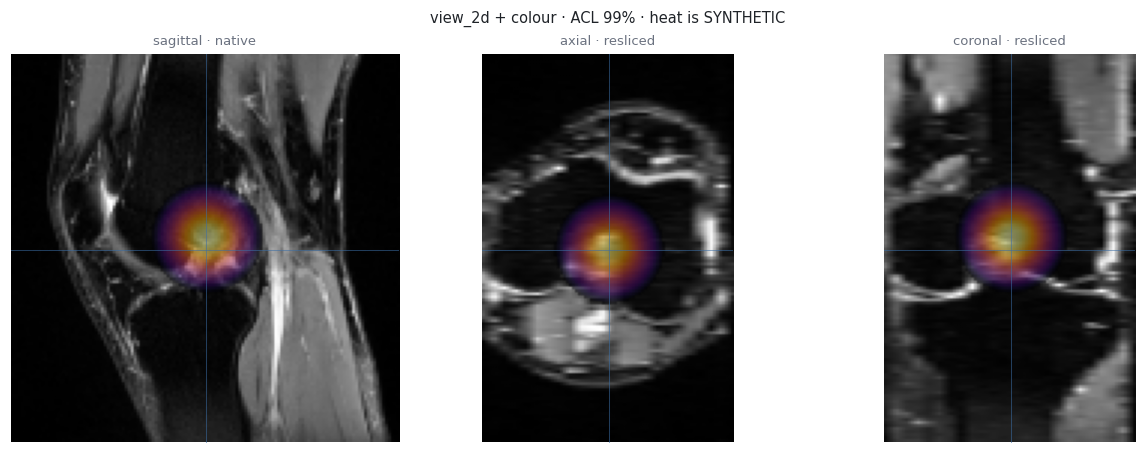

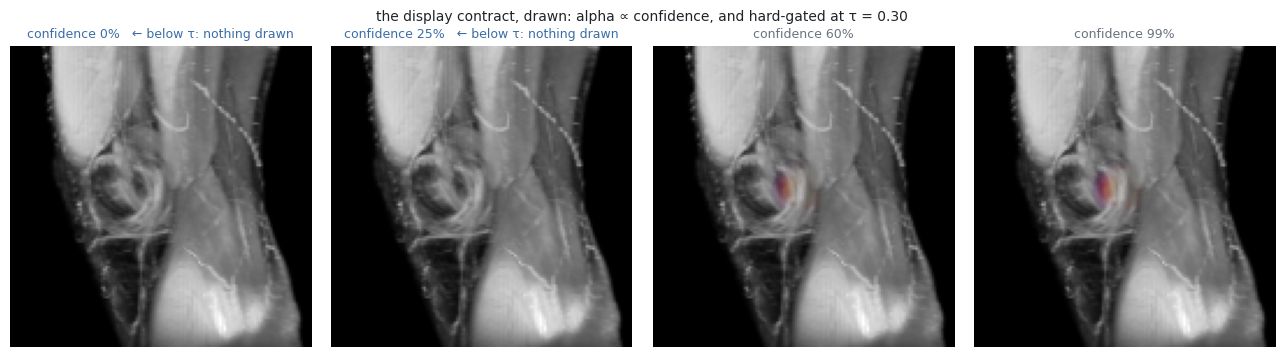

In [15]:
H = fake_heat(W.shape)                       # same blob on the un-padded grid, for the 2D views
triplanar(W, heat=H, conf=probs[LABEL],
          title=f"view_2d + colour · {LABEL} {probs[LABEL]:.0%} · heat is SYNTHETIC")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), dpi=100)
for ax, conf in zip(axes, [0.0, 0.25, 0.60, float(probs[LABEL])]):
    ax.imshow(raycast(Wc, 25, heat=Hc, conf=conf))
    ax.set_title(f"confidence {conf:.0%}" + ("   ← below τ: nothing drawn" if conf < TAU_CONF else ""),
                 color=(MUTED if conf >= TAU_CONF else HUE))
    ax.set_axis_off()
fig.suptitle("the display contract, drawn: alpha ∝ confidence, and hard-gated at τ = %.2f" % TAU_CONF,
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

In [16]:
turntable(Wc, heat=Hc, conf=float(probs[LABEL]),
          title=f"view_3d · {LABEL} {probs[LABEL]:.0%} · SYNTHETIC heat")

---
## 11. The study, not the series — and why we do not fuse the planes

The brief says "3 axes". A study already **contains** three real acquisitions, one per plane.
The alternative — reslicing one plane into the other two — is what §5 of this notebook does, and
the comparison below is the argument: top row acquired, bottom row manufactured from the
sagittal stack alone.

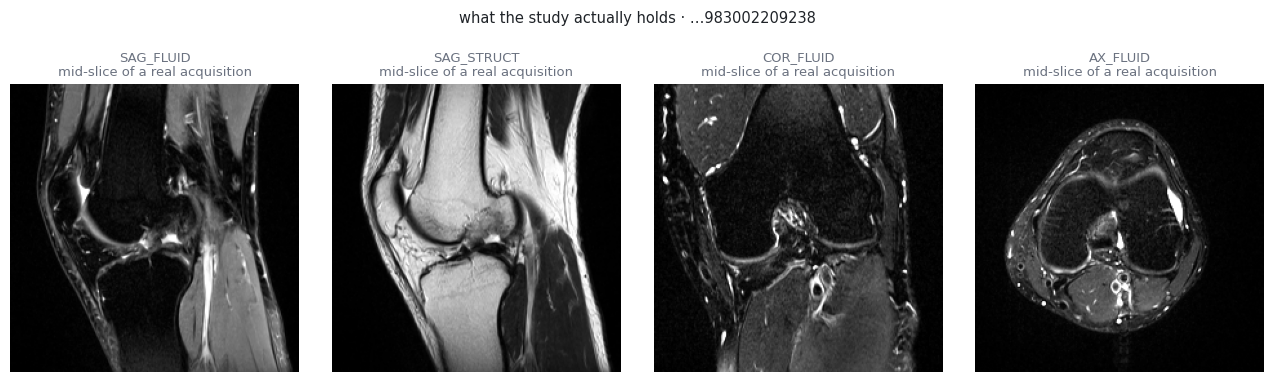

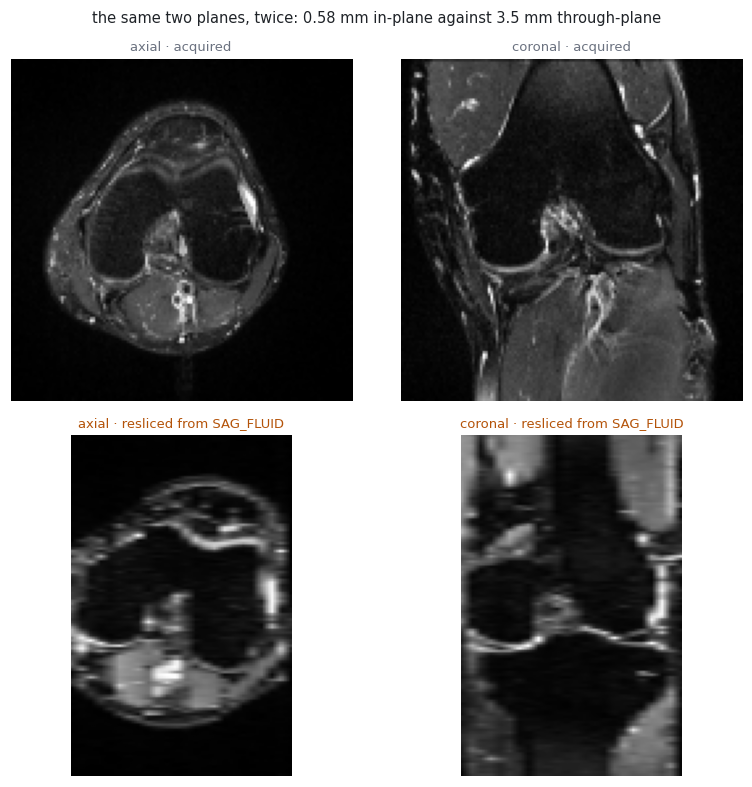

In [17]:
present = {k: v for k, v in slots.items() if v}
vols    = {k: window(load_series(v)) for k, v in present.items()}

fig, axes = plt.subplots(1, len(vols), figsize=(3.1*len(vols), 3.4), dpi=105)
for ax, (name, Vi) in zip(np.atleast_1d(axes), vols.items()):
    ax.imshow(Vi[len(Vi)//2], cmap="gray", vmin=0, vmax=1); ax.set_axis_off()
    ax.set_title(f"{name}\nmid-slice of a real acquisition", color=MUTED)
fig.suptitle(f"what the study actually holds · …{STUDY[-12:]}", fontsize=10, color=INK, y=1.06)
plt.tight_layout(); plt.show()

# acquired vs resliced, same anatomical plane
Wax  = to_iso(vols["AX_FLUID"])  if "AX_FLUID"  in vols else None
Wcor = to_iso(vols["COR_FLUID"]) if "COR_FLUID" in vols else None
pairs = [("axial",   None if Wax  is None else Wax[len(Wax)//2],   W[:, W.shape[1]//2, :].T),
         ("coronal", None if Wcor is None else Wcor[len(Wcor)//2], W[:, :, W.shape[2]//2].T)]
fig, axes = plt.subplots(2, 2, figsize=(7.6, 7.6), dpi=105)
for col, (name, acq, res) in enumerate(pairs):
    for row, (img, tag) in enumerate([(acq, "acquired"), (res, "resliced from SAG_FLUID")]):
        ax = axes[row, col]; ax.set_axis_off()
        if img is None: ax.text(.5, .5, "slot missing", ha="center", color=MUTED); continue
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{name} · {tag}", color=(MUTED if row == 0 else "#b45309"))
fig.suptitle("the same two planes, twice: 0.58 mm in-plane against 3.5 mm through-plane",
             fontsize=10, color=INK)
plt.tight_layout(); plt.show()

That bottom row is why `build_render_pack` takes **one** series for anatomy and the plan says
*"no cross-plane fusion: three anisotropic anatomies resample into a blurry pancake"*. The three
acquisitions belong in the app **side by side**, each read in its own plane — and the heat
volume, which is coarse (~8 mm per token) and smooth, is the only thing that crosses between
them without lying about resolution.

---
## 12. The render pack — what the app actually loads

Everything above reads the mirror, which the app will not have. `build_render_pack` collapses a
study into one self-contained `.npz`: anatomy, one heat volume per label, spacing, and the 12
probabilities. It is a *dumb* file — no model, no DICOM, no resampling at view time.

`heat_iso` is half resolution on purpose: M6a's tokens are ~8 mm, so storing the heat at 1 mm
would be four times the bytes for zero information.

In [18]:
def build_render_pack(study, out_dir=DATA/"render_packs", n=128, hn=64, iso_mm=ISO_MM):
    """study -> one .npz the viewer can open with no other file present.
       gray_iso uint8 (n,n,n) · heat_iso uint8 (12,hn,hn,hn) · spacing · probs[12]"""
    s = study_slots(study)
    anat = s["SAG_FLUID"] or s["SAG_STRUCT"] or next(v for v in s.values() if v)
    Wi   = cube(to_iso(window(load_series(anat)), iso_mm=iso_mm))
    gray = ndi.zoom(Wi, n/Wi.shape[0], order=1)

    heat = np.stack([fake_heat((hn, hn, hn), iso_mm=iso_mm*Wi.shape[0]/hn) for _ in LABELS])   # <- M6a swaps in here
    p    = idx.loc[idx.StudyInstanceUID == study, [f"soft_{c}" for c in LABELS]].iloc[0].values.astype(np.float32)

    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir/f"{study}.npz"
    np.savez_compressed(path,
        gray_iso=np.clip(gray*255, 0, 255).astype(np.uint8),
        heat_iso=np.clip(heat*255, 0, 255).astype(np.uint8),
        spacing=np.float32([iso_mm*Wi.shape[0]/n]*3),
        probs=p, labels=np.array(LABELS), anatomy_series=np.array(anat),
        heat_is_synthetic=np.array(True))     # remove the day M6a is real. Never ship it True.
    return path

pack_path = build_render_pack(STUDY)
print(f"wrote {pack_path.relative_to(ROOT)}  ({pack_path.stat().st_size/2**20:.1f} MiB)")
with np.load(pack_path) as z:
    for k in z.files:
        a = z[k]
        print(f"  {k:18s} {str(a.shape):18s} {a.dtype}")

wrote data/render_packs/1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238.npz  (1.0 MiB)
  gray_iso           (128, 128, 128)    uint8
  heat_iso           (12, 64, 64, 64)   uint8
  spacing            (3,)               float32
  probs              (12,)              float32
  labels             (12,)              <U16
  anatomy_series     ()                 <U64
  heat_is_synthetic  ()                 bool


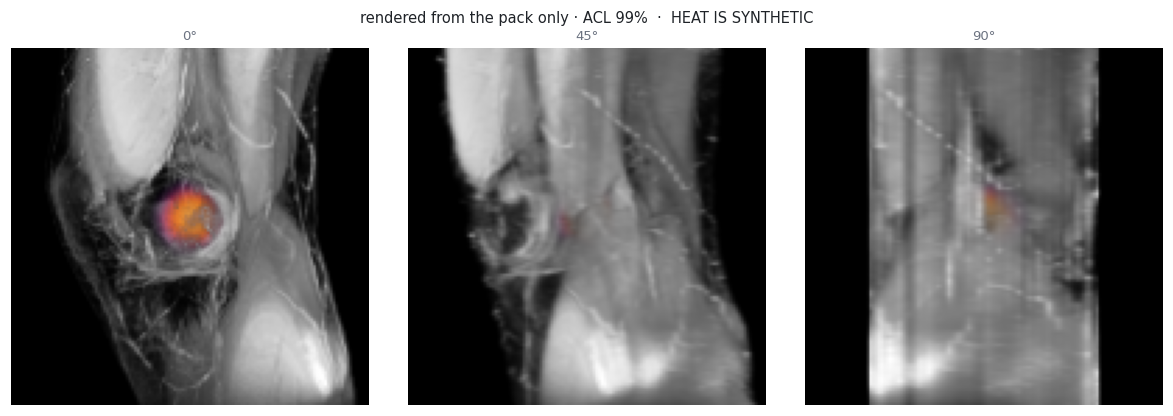

the 12 percentages the app returns (placeholder values — soft report labels, not M5):

  ACL                99.0%  ████████████████████████████
  Medial Meniscus    97.5%  ███████████████████████████
  Baker's            25.0%  ███████
  Synovitis          13.8%  ████
  MCL                 2.5%  █
  Lateral Meniscus    2.5%  █
  Medial OA           2.5%  █
  Lateral OA          2.5%  █
  PF OA               2.5%  █
  Effusion            2.5%  █
  Contusion           2.5%  █
  Fracture            2.5%  █

no sentence, no conclusion — by design (project_introduction.md).


In [19]:
# The app path, end to end: open the pack and render from it alone.
with np.load(pack_path) as z:
    gray = z["gray_iso"].astype(np.float32)/255.
    heat = z["heat_iso"].astype(np.float32)/255.
    prob = pd.Series(z["probs"], index=[str(x) for x in z["labels"]])
    synth = bool(z["heat_is_synthetic"])

k = LABELS.index(LABEL)
hk = ndi.zoom(heat[k], gray.shape[0]/heat[k].shape[0], order=1)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.0), dpi=105)
for ax, az in zip(axes, [0, 45, 90]):
    ax.imshow(raycast(gray, az, heat=hk, conf=float(prob[LABEL]))); ax.set_axis_off()
    ax.set_title(f"{az}°", color=MUTED)
fig.suptitle(f"rendered from the pack only · {LABEL} {prob[LABEL]:.0%}"
             + ("  ·  HEAT IS SYNTHETIC" if synth else ""), fontsize=10, color=INK)
plt.tight_layout(); plt.show()

top = prob.sort_values(ascending=False)
print("the 12 percentages the app returns (placeholder values — soft report labels, not M5):\n")
for c, v in top.items():
    print(f"  {c:<18s} {v:5.1%}  {'█'*int(round(v*28))}")
print("\nno sentence, no conclusion — by design (project_introduction.md).")

---
## 13. Optional — the same pack in a browser-side 3D widget

`plotly` is the plan's Stage-3 dependency (`plotly>=6.0`, browser-side, survives Streamlit
Cloud). It is not installed here, and nothing above needs it. The cell degrades to a message and
the install line rather than an exception, so this notebook always runs top to bottom.

In [20]:
try:
    import plotly.graph_objects as go
    step = 2                                   # 64^3 is plenty for a browser volume
    g = gray[::step, ::step, ::step]
    zz, yy, xx = np.mgrid[0:g.shape[0], 0:g.shape[1], 0:g.shape[2]]
    fig = go.Figure(go.Volume(
        x=xx.ravel(), y=yy.ravel(), z=zz.ravel(), value=g.ravel(),
        isomin=.12, isomax=1.0, opacity=.08, surface_count=16, colorscale="Gray",
        caps=dict(x_show=False, y_show=False, z_show=False)))
    fig.update_layout(width=620, height=560, margin=dict(l=0, r=0, t=30, b=0),
                      title=f"drag to rotate · study …{STUDY[-12:]}")
    fig.show()
except ImportError:
    print("plotly not installed — every view above is matplotlib-only and unaffected.")
    print("for the interactive widget:  pip install 'plotly>=6.0'")

plotly not installed — every view above is matplotlib-only and unaffected.
for the interactive widget:  pip install 'plotly>=6.0'


---
## What to take from here

**Reusable now.** `load_series · window · to_iso · triplanar · mip · raycast · turntable ·
planes3d · build_render_pack` are written to move to `src/viz/` unchanged. `viewer.py` is a thin
Streamlit shell over them plus a slot picker.

**The one assumption.** `SLICE_MM = 3.5`. It scales the z axis of §5–§12 and nothing else — no
2D view depends on it. Fix it by having M2 write `slice_spacing_mm` into the pack; it already
computes it.

**The one lie, clearly marked.** Every heat volume here is a Gaussian blob. It satisfies M6a's
contract so the viewer is finished before the CAMs exist — `heat_is_synthetic=True` rides in the
pack so nothing can quietly demo it as real.

**Weight.** The embedded figures and the two animations are ~6 MiB of this file. That is the
point — it renders on GitHub with no data checked out — but `jupyter nbconvert --clear-output
--inplace notebooks/img_visual.ipynb` before a commit if a branch needs to stay light.

**Next.** Batch `build_render_pack` over the 58 gold studies (~5 MiB each, ~290 MiB) and the
demo has its whole corpus precomputed, model or no model.